In [199]:
#we are going to predict names, or make new names from patterns in this dataset.
import math,numpy
words = open('names.txt','r').read().splitlines()

In [4]:
import sys
print(sys.executable)

/Users/danisharshid/Desktop/Final_Plan /Deep Learning/bigram/.venv/bin/python


In [5]:
words[0:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [6]:
len(words)

32033

In [7]:
#check the minimum length name
min(len(w) for w in words)

2

In [8]:
max(len(w) for w in words)

15

In [9]:
#check the bigram available in the first word
for w in words[:1]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        print(ch1, ch2)

<S> e
e m
m m
m a
a <E>


In [10]:
#count the frequency of each bigram
b = {} #bigram -> count in the dataset
for w in words:
        chs = ['<S>'] + list(w) + ['<E>']
        for ch1,ch2 in zip(chs,chs[1:]):
            bigram = (ch1,ch2)
            b[bigram] = b.get(bigram,0) + 1
sorted(b.items(),key = lambda kv:-kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [2]:
import torch 

In [13]:
N = torch.zeros((28,28), dtype = torch.int32)
N

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [16]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i for i,s in enumerate(chars)}
stoi["<S>"] = 26
stoi["<E>"] = 27
print(stoi)

{'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25, '<S>': 26, '<E>': 27}


In [19]:
for w in words:
        chs = ['<S>'] + list(w) + ['<E>']
        for ch1,ch2 in zip(chs,chs[1:]):
            ix1,ix2 = stoi[ch1],stoi[ch2]
            N[ix1,ix2] += 1


In [22]:
itos = {i:s for s,i in stoi.items()}

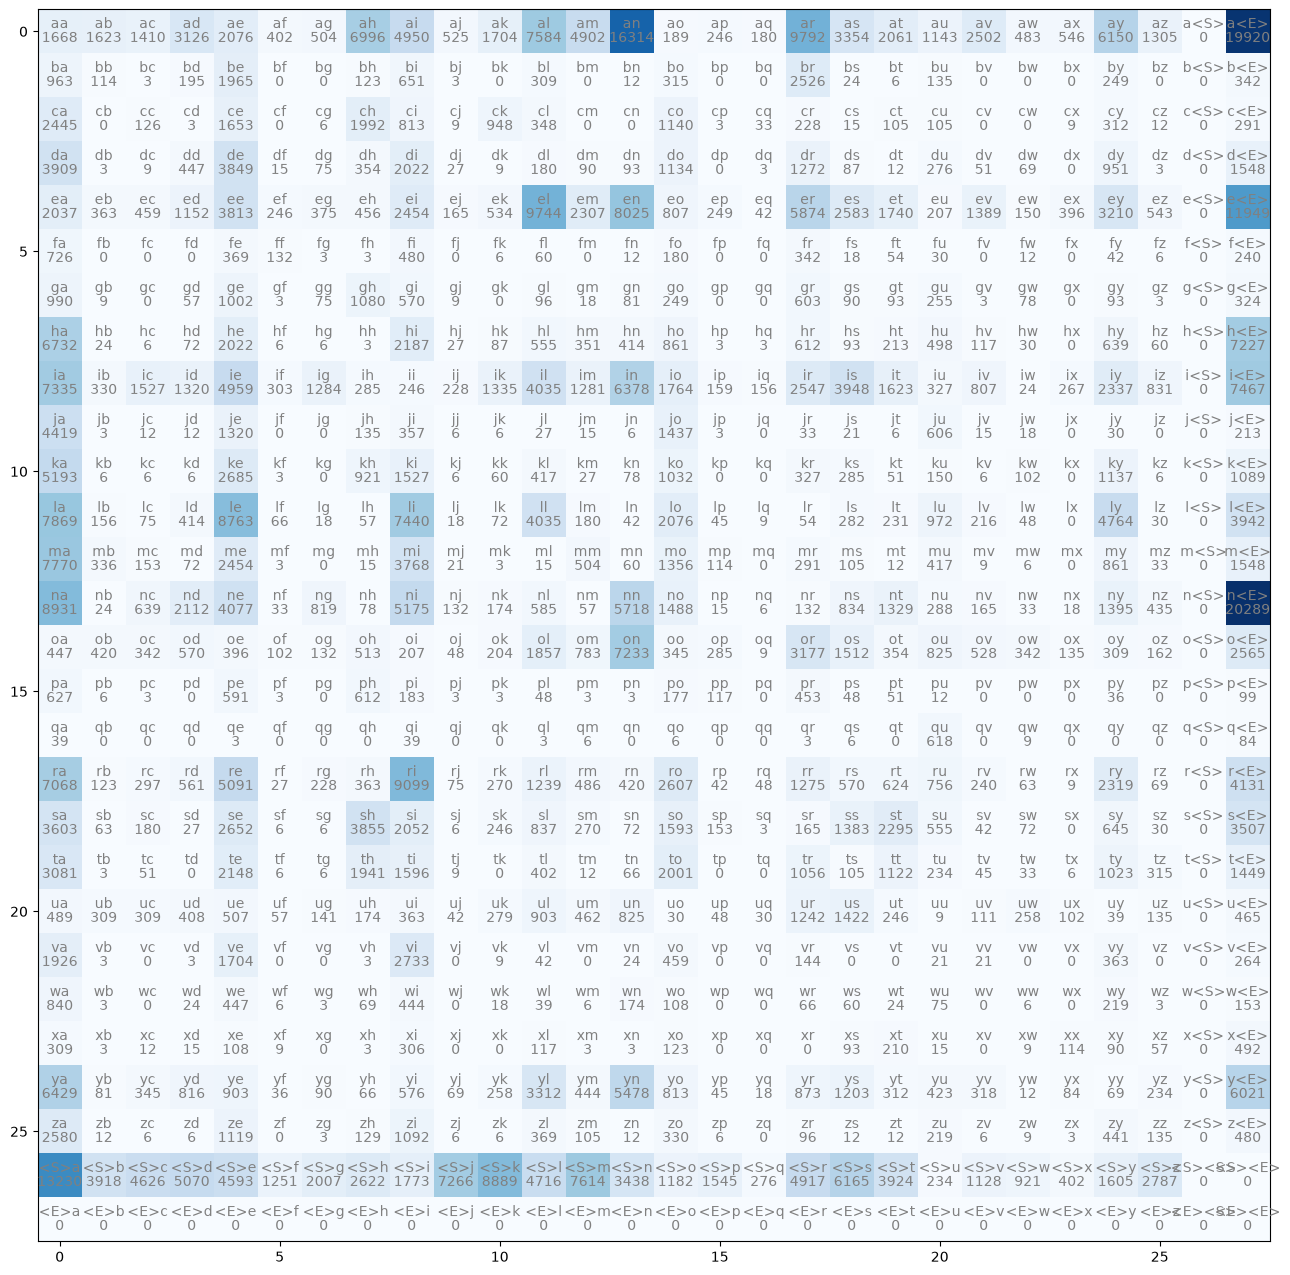

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,16))
plt.imshow(N,cmap='Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j,i,chstr,ha = "center",va="bottom",color = 'gray')
        plt.text(j,i,N[i,j].item(),ha='center',va="top",color='gray')

In [ ]:
#let's fix above where there are <E>char entire row is zero and char<S> entire col is zero, therefore we need to reduce these
#also for special chars it is typical to use <S> and <E> in nlp but it is getting crowded

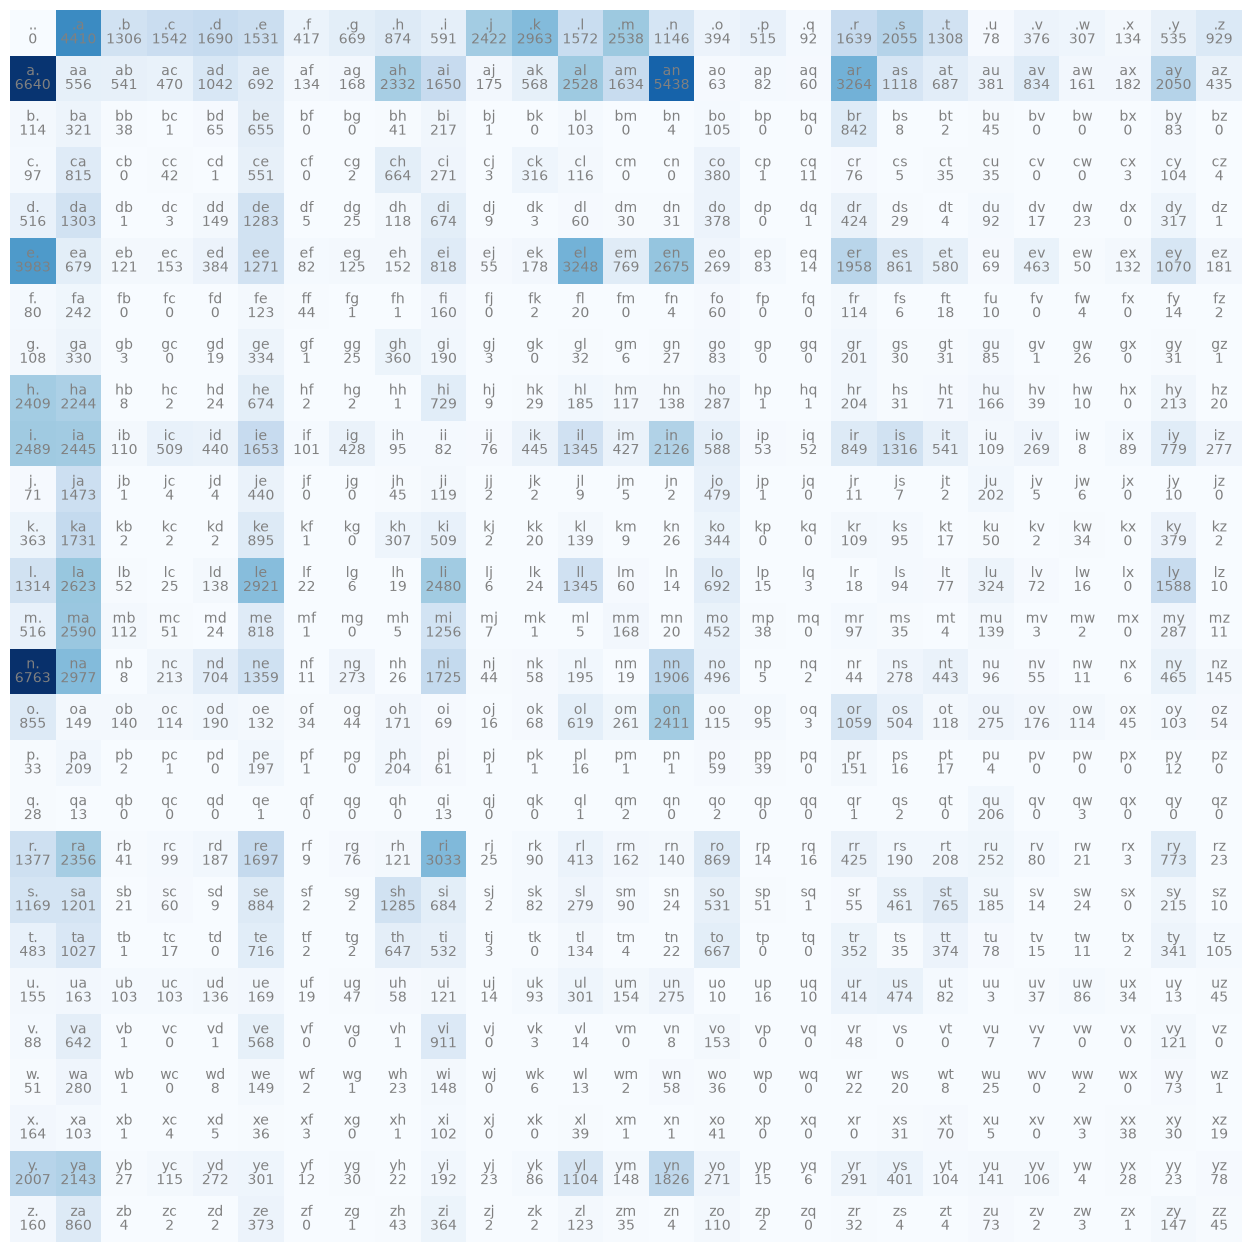

In [156]:
N = torch.zeros((27,27), dtype = torch.int32)
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
# print(stoi)
for w in words:
        chs = ['.'] + list(w) + ['.']
        for ch1,ch2 in zip(chs,chs[1:]):
            ix1,ix2 = stoi[ch1],stoi[ch2]
            N[ix1,ix2] += 1

itos = {i:s for s,i in stoi.items()}
import matplotlib.pyplot as plt
plt.figure(figsize=(16,16))
plt.imshow(N,cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j,i,chstr,ha = "center",va="bottom",color = 'gray')
        plt.text(j,i,N[i,j].item(),ha='center',va="top",color='gray')
    plt.axis('off')

In [157]:
N[0,:]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [158]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [159]:
P = N[0].float()
P /= P.sum()
P

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [160]:
P.sum()
#p gives the probability of each name starting with a or b or c .. z

tensor(1.)

In [ ]:
#sampling from the Model : 

In [161]:

g = torch.Generator().manual_seed(2147483647) #for always getting same numbers
p = torch.rand(3,generator = g) #the random numbers
p /= p.sum()
p



tensor([0.6064, 0.3033, 0.0903])

In [162]:
torch.multinomial(p,num_samples=10,replacement = True, generator = g)
# you'll get the same sequence of samples every time you run the same sampling operation from the same generator state.

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0])

In [163]:
#lets apply above to our model
g = torch.Generator().manual_seed(2147483647)
p = N[0].float()
p /= P.sum()



In [164]:
ix = torch.multinomial(p,num_samples=1,replacement = True, generator = g).item()
itos[ix]

'c'

In [208]:
P = (N+1).float() #model smoothing 
P /= P.sum(1,keepdim=True)
# 27, 27
# 27, 1 check out brodcasting semantics rules in torch
# P.sum(1,keepdim=True).shape
# P[0,:].sum()
# P[2].sum()

In [198]:
#let's predict next Likely characters using the model above
g = torch.Generator().manual_seed(2147483647)

for i in range(10): #how many names we want to generate
    out = []
    ix = 0 #start from empty string
    while True:
        # p = N[ix].float()
        # p /= p.sum()
        p = P[ix]
        ix = torch.multinomial(p,num_samples=1,replacement = True, generator = g).item()
        out.append(itos[ix])
        if ix == 0: #word has ended
            break
    print(''.join(out))
        

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [ ]:
# We're measuring how well the learned probability distribution
# explains the words, rather than judging the model from whatever
# random word it happens to generate.

# Conditional probabilities are multiplied together here to quantify
# how well the model predicts the observed word "emma":
# P(e|.) * P(m|e) * P(m|m) * P(a|m) * P(.|a)
# log(a*b*c) = log(a) + log(b) + log(c) -> and log is monotonic
loglikelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w) +['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1,ix2 = stoi[ch1],stoi[ch2]
        logprob = torch.log(P[ix1,ix2])
        loglikelihood += logprob
        n += 1

print(f"loglikelihood = {loglikelihood/n}")
print(f"negativeloglikelihood = {-1*loglikelihood/n}")

#we want negativeloglikelihood to be as minimum as possible nll/n summarizes the quality of model and we
#want to minimize it


loglikelihood = -2.454094171524048
negativeloglikelihood = 2.454094171524048


In [ ]:
#using above model we can calculate prob of any word
loglikelihood = 0.0
n = 0
for w in ["danishjz"]:
       chs = ['.'] + list(w) +['.']
       for ch1,ch2 in zip(chs,chs[1:]):
            ix1,ix2 = stoi[ch1],stoi[ch2]
            logprob = torch.log(P[ix1,ix2])
            loglikelihood += logprob
            n += 1
    
print(f"loglikelihood = {loglikelihood/n}")
print(f"negativeloglikelihood = {-1*loglikelihood/n}")
#we can see "danishjz" is a very unlikely word because our model says probability of z after j is 0
#this can be a likely name, and we want to fix the model and we use what is known as model smoothing
#add a constant to zero values more you add more smoother the distribution becomes

loglikelihood = -inf
negativeloglikelihood = inf


In [ ]:
#after applying model smoothing
loglikelihood = 0.0
n = 0
for w in ["danishjz"]:
       chs = ['.'] + list(w) +['.']
       for ch1,ch2 in zip(chs,chs[1:]):
            ix1,ix2 = stoi[ch1],stoi[ch2]
            logprob = torch.log(P[ix1,ix2])
            loglikelihood += logprob
            n += 1
    
print(f"loglikelihood = {loglikelihood/n}")
print(f"negativeloglikelihood = {-1*loglikelihood/n}")

loglikelihood = -3.3730051517486572
negativeloglikelihood = 3.3730051517486572


## Building the same above model using Neural Networks ##



In [216]:
# create the training set of bigrams
xs, ys = [],[]
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1,ix2 = stoi[ch1],stoi[ch2]
        print(ch1,ch2)
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [278]:
# xs.dtype return int64
xs

tensor([ 0,  5, 13, 13,  1])

In [215]:
ys

tensor([ 5, 13, 13,  1,  0])

In [279]:
#one hot encoding
import torch.nn.functional as F
xenc = F.one_hot(xs,num_classes=27).float() #because we need to feed in floats to neural net
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [280]:
xenc.shape #each row of xenc is a vector representing the index of the character 

torch.Size([5, 27])

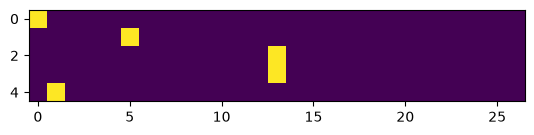

In [265]:
plt.imshow(xenc)

In [266]:
W = torch.randn((27,27)) #sampling from normal distribution: look up the curve of normal distrib

ypred = xenc @ W
ypred

tensor([[-1.7973e-01, -2.9084e-01, -1.2726e-01, -9.6114e-01,  7.2687e-01,
          6.5190e-01,  2.1385e+00, -1.4355e+00,  3.9701e-01,  1.5554e+00,
          2.1918e-01, -1.1938e-01, -1.9200e+00, -1.9436e+00, -6.6826e-02,
          1.3604e-01,  1.5073e+00,  5.9048e-01,  4.2768e-01,  1.8896e+00,
         -8.9760e-01,  5.1341e-01,  4.3333e-01,  1.1177e-01,  4.5675e-01,
          3.9433e-01,  1.8256e+00],
        [ 1.9013e+00,  1.5874e+00,  9.7592e-02,  1.4923e+00,  1.1773e-01,
          1.4355e+00, -3.9531e-02, -4.5615e-01, -3.1887e+00,  1.6419e+00,
         -2.8966e-01, -9.3002e-01, -4.4805e-01,  1.1122e+00,  2.2509e+00,
         -7.1236e-01, -2.1441e-01, -7.9078e-01,  4.6076e-01,  2.8587e-01,
          2.6349e+00,  8.5952e-01, -4.0423e-01,  1.5618e+00, -1.3009e-01,
          7.3860e-01,  6.7816e-01],
        [-1.4362e-02,  5.4220e-01, -7.4708e-01,  1.7505e+00,  2.9041e-01,
          3.9062e-01,  2.0679e+00, -6.0536e-01,  2.4132e-01,  8.6927e-01,
          1.6673e-03, -1.7240e+00,  8.11

In [267]:
ypred.shape

torch.Size([5, 27])

In [268]:
ypred[3,13].item() #for training example 4 i.e if char first is m what is the prob of next character being m

-0.4297974407672882

In [269]:
(xenc[3]*W[:,13]).sum().item() #same as above

-0.4297974407672882

In [270]:
#so the ouputs aren't representing probabilities because they are negative here let's introduce something to make it 
#closer to predicting prob
#if we apply exp() to each value that would make it positive and then if we normalize that we get prob.
logits = xenc @ W #interpret as log counts
counts = logits.exp() # equivalent to N
probs = counts/counts.sum(1,keepdim=True) #sum along the rows and keep the dimension 
probs # we made it such that we can interpret the outputs as probabilities

#above we have done differentiable operations we can backprop through and we are getting out prob distributions.


tensor([[0.0153, 0.0137, 0.0161, 0.0070, 0.0378, 0.0350, 0.1550, 0.0043, 0.0272,
         0.0865, 0.0227, 0.0162, 0.0027, 0.0026, 0.0171, 0.0209, 0.0824, 0.0330,
         0.0280, 0.1208, 0.0074, 0.0305, 0.0282, 0.0204, 0.0288, 0.0271, 0.1133],
        [0.0893, 0.0653, 0.0147, 0.0594, 0.0150, 0.0561, 0.0128, 0.0085, 0.0006,
         0.0689, 0.0100, 0.0053, 0.0085, 0.0406, 0.1267, 0.0065, 0.0108, 0.0061,
         0.0212, 0.0178, 0.1861, 0.0315, 0.0089, 0.0636, 0.0117, 0.0279, 0.0263],
        [0.0185, 0.0323, 0.0089, 0.1081, 0.0251, 0.0278, 0.1485, 0.0103, 0.0239,
         0.0448, 0.0188, 0.0033, 0.0423, 0.0122, 0.0141, 0.0261, 0.0044, 0.0232,
         0.0247, 0.1799, 0.0217, 0.0564, 0.0060, 0.0583, 0.0374, 0.0135, 0.0094],
        [0.0185, 0.0323, 0.0089, 0.1081, 0.0251, 0.0278, 0.1485, 0.0103, 0.0239,
         0.0448, 0.0188, 0.0033, 0.0423, 0.0122, 0.0141, 0.0261, 0.0044, 0.0232,
         0.0247, 0.1799, 0.0217, 0.0564, 0.0060, 0.0583, 0.0374, 0.0135, 0.0094],
        [0.0073, 0.0105,

In [271]:
probs[0].sum()

tensor(1.)

In [276]:
##summary of what we have done so far in neural nets here
xs #indices of the first characters in the bigrams of word emma : .e,em,mm,ma,a.

tensor([ 0,  5, 13, 13,  1])

In [273]:
ys #indices of the second characters in the bigrams of word emma : .e,em,mm,ma,a. , will act as actual labels

tensor([ 5, 13, 13,  1,  0])

In [283]:
#randomly initialize 27 neurons' weights and each one of these neurons receive 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27),generator=g)

In [284]:
#the forward pass
# xenc = F.one_hot(xs) #input to the network : one_hot encoding
logits = xenc @ W # log counts : we interpret this way
counts = logits.exp() # counts , equivalent to N
probs = counts/counts.sum(1,keepdim=True) #probabilities for next character
#the last two lines above together are called softmax

In [285]:
#this code will be to visualise what is being done by forward pass above for the example word emma : .e,em,mm,ma,a. 
nlls = torch.zeros(5)
for i in range(5):
    x = xs[i].item()
    y = ys[i].item()
    print("-----------")
    print(f"bigram example {i+1} : {itos[x]}{itos[y]}")
    print(f"input to the neural net : {x}")
    print(f"output probabilities from the neural net: {probs[i]}")
    print(f"label(acutual next character) : {y}")
    p = probs[i,y]
    print(f"prob assigned by net to actual character : {p.item()}")
    logp = torch.log(p)
    print(f"logLikeLihood{logp.item()}")
    nll = -logp
    print(f"negative log likelihood : {nll.item()}")
    nlls[i] = nll

print("============================")
print(f"average negative log likelihood i.e., loss = {nlls.mean().item()}")


-----------
bigram example 1 : .e
input to the neural net : 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label(acutual next character) : 5
prob assigned by net to actual character : 0.012286250479519367
logLikeLihood-4.3992743492126465
negative log likelihood : 4.3992743492126465
-----------
bigram example 2 : em
input to the neural net : 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label(acutual next character) : 13
prob assigned by net to actual character : 0.018050704151391983
logLikeLihood-4.014570713043213
neg

In [287]:
#for the above example
probs[0,5],probs[1,13],probs[2,13],probs[3,1],probs[4,0] # probs[0,5] on example 0(.) what is the prob of actual char 5(e)

(tensor(0.0123),
 tensor(0.0181),
 tensor(0.0267),
 tensor(0.0737),
 tensor(0.0150))

In [289]:
probs[(torch.arange(5),ys)]

tensor([0.0123, 0.0181, 0.0267, 0.0737, 0.0150])

In [520]:
#optimization 

#create the dataset
xs, ys = [],[]
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1,ix2 = stoi[ch1],stoi[ch2]
        # print(ch1,ch2)
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print("number of examples : ",num)

#initialize the network
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27),generator=g,requires_grad=True)
print(xs.shape)

number of examples :  228146
torch.Size([228146])


In [539]:
#gradient descent same loop as our MLP loop
for k in range(10):

    #forward pass
    xenc = F.one_hot(xs,num_classes = 27).float()
    logits = xenc @ W 
    counts = logits.exp()
    probs = counts/counts.sum(1,keepdim=True)
    #torch.arange(num) gives 0,1,2,....num-1 and ys gives indices of labels we want
    loss = -probs[torch.arange(num),ys].log().mean()
    print(loss.item())

    #backward pass
    W.grad = None # to set the grads to 0 for all nodes in computation graph
    loss.backward()

    #update
    W.data += -50*W.grad

2.4634039402008057
2.4633448123931885
2.4632863998413086
2.463228940963745
2.4631717205047607
2.4631154537200928
2.463059902191162
2.4630050659179688
2.4629504680633545
2.4628970623016357


In [ ]:
#the first approach is not scalable and neural net approach is scalable and this is what we can improve on over time.

## Correlations between the two approaches for the same problem above.